In [11]:
# Import Deep Learning Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

In [12]:
# Load dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Training data shape:", x_train.shape)
print("Testing data shape:", x_test.shape)

Training data shape: (60000, 28, 28)
Testing data shape: (10000, 28, 28)


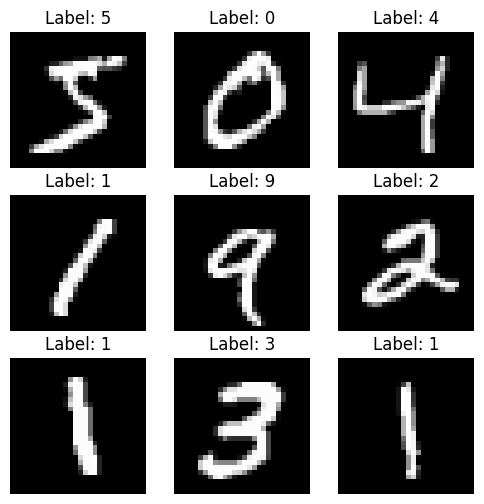

In [13]:
plt.figure(figsize=(6,6))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title("Label: "+str(y_train[i]))
    plt.axis("off")

plt.show()

In [14]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [15]:
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

print(x_train.shape)


(60000, 784)


In [16]:
model = keras.Sequential([

    layers.Dense(128, activation='relu', input_shape=(784,)),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')

])

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9207 - loss: 0.2691 - val_accuracy: 0.9614 - val_loss: 0.1312
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9648 - loss: 0.1121 - val_accuracy: 0.9639 - val_loss: 0.1220
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9770 - loss: 0.0744 - val_accuracy: 0.9734 - val_loss: 0.0907
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9830 - loss: 0.0547 - val_accuracy: 0.9706 - val_loss: 0.0976
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9858 - loss: 0.0428 - val_accuracy: 0.9699 - val_loss: 0.1086
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9890 - loss: 0.0344 - val_accuracy: 0.9756 - val_loss: 0.0963
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9905 - loss: 0.0280 - val_accuracy: 0.9739 - val_loss: 0.1081
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9921 - loss: 0.0229 - 

test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

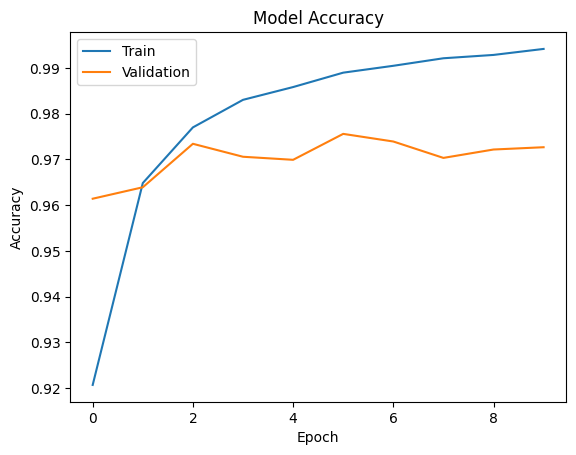

In [19]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Validation'])

plt.show()

In [20]:
predictions = model.predict(x_test)

print("Predicted Digit:", np.argmax(predictions[0]))
print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted Digit: 7
Actual Digit: 7


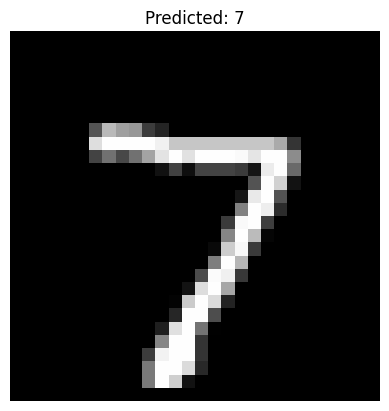

In [21]:
plt.imshow(x_test[0].reshape(28,28), cmap='gray')
plt.title("Predicted: "+str(np.argmax(predictions[0])))
plt.axis("off")
plt.show()